In [1]:
#%pip install pandas
#%pip install sklearn
%pip install xgboost
%pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score,recall_score

In [3]:
card_dataset = pd.read_csv("credit_card_clean.csv")
card_dataset

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,female,university,married,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,female,university,single,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,female,university,single,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,female,university,married,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,male,university,married,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,male,highschool,married,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,male,highschool,single,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,male,university,single,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,male,highschool,married,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [ ]:
## 3. Data Understanding

### Exploring the variable
* ID : ID of each client

* LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit)

* SEX: Gender (1=male, 2=female)

* EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)

* MARRIAGE: Marital status (1=married, 2=single, 3=others)

* AGE: Age in years

* PAY_1: Repayment status in September, 2005 (-2 = No consumption, -1 = paid in full, 0 = use of revolving credit (paid minimum only), 1 = payment delay for one month, 2 = payment delay for two months, ... 8 = payment delay for eight months, 9 = payment delay for nine months and above)

* PAY_2: Repayment status in August, 2005 (scale same as above)

* PAY_3: Repayment status in July, 2005 (scale same as above)

* PAY_4: Repayment status in June, 2005 (scale same as above)

* PAY_5: Repayment status in May, 2005 (scale same as above)

* PAY_6: Repayment status in April, 2005 (scale same as above)

* BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)

* BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)

* BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)

* BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)

* BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)

* BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)

* PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)

* PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)

* PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)

* PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)

* PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)

* PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)

#### Target variable
default.payment.next.month: Default payment (1=yes, 0=no)

###### Note: NT is Taiwain Dollars

In [4]:
le = LabelEncoder()
card_dataset['SEX'] = le.fit_transform(card_dataset['SEX'])
card_dataset['EDUCATION'] = le.fit_transform(card_dataset['EDUCATION'])
card_dataset['MARRIAGE'] = le.fit_transform(card_dataset['MARRIAGE'])

In [5]:
card_dataset.drop('ID', axis = 1, inplace = True)
card_dataset

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,0,3,0,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,0,3,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,0,3,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,0,3,0,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,3,0,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,1,0,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,1,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,3,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,1,0,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [6]:
X = card_dataset.drop('DEFAULT', axis=1)
Y = card_dataset['DEFAULT']
X.shape,Y.shape

((30000, 23), (30000,))

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, shuffle=True, random_state= 123,  stratify=Y)

In [21]:
ada_boosting = AdaBoostClassifier()
gradient_boosting = GradientBoostingClassifier(n_estimators = 50)
xgbm_boosting = XGBClassifier(n_estimators = 200)
lightbgm_boosting = LGBMClassifier(n_estimators = 200)

In [22]:
%%time
ada_boosting.fit(X_train, Y_train)

CPU times: user 930 ms, sys: 5.57 ms, total: 936 ms
Wall time: 943 ms


AdaBoostClassifier()

In [23]:
%%time
gradient_boosting.fit(X_train, Y_train)

CPU times: user 2.33 s, sys: 8.84 ms, total: 2.34 s
Wall time: 2.34 s


GradientBoostingClassifier(n_estimators=50)

In [24]:
%%time
xgbm_boosting.fit(X_train, Y_train)

CPU times: user 473 ms, sys: 503 ms, total: 976 ms
Wall time: 324 ms


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [25]:
%%time
lightbgm_boosting.fit(X_train, Y_train)

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000411 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3259
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
CPU times: user 714 ms, sys: 1.98 s, total: 2.69 s
Wall time: 884 ms


LGBMClassifier(n_estimators=200)

In [27]:
Y_pred_ada = ada_boosting.predict(X_test)
Y_pred_grd = gradient_boosting.predict(X_test)
Y_pred_xgbm = xgbm_boosting.predict(X_test)
Y_pred_lgbm = lightbgm_boosting.predict(X_test)

In [19]:
print("Accuracy Score:",round(accuracy_score(Y_test,Y_pred_ada),4))
print("Precision Score:",round(precision_score(Y_test,Y_pred_ada),4))
print("Recall Score",round(recall_score(Y_test,Y_pred_ada)),4)
print("Confusion Matrix\n",confusion_matrix(Y_test,Y_pred_ada))

Accuracy Score: 0.8099
Precision Score: 0.6503
Recall Score 0 4
Confusion Matrix
 [[5570  271]
 [1155  504]]


In [28]:
print("Accuracy Score:",round(accuracy_score(Y_test,Y_pred_grd),4))
print("Precision Score:",round(precision_score(Y_test,Y_pred_grd),4))
print("Recall Score",round(recall_score(Y_test,Y_pred_grd)),4)
print("Confusion Matrix\n",confusion_matrix(Y_test,Y_pred_grd))

Accuracy Score: 0.8233
Precision Score: 0.6949
Recall Score 0 4
Confusion Matrix
 [[4464  209]
 [ 851  476]]


In [29]:
print("Accuracy Score:",round(accuracy_score(Y_test,Y_pred_xgbm),4))
print("Precision Score:",round(precision_score(Y_test,Y_pred_xgbm),4))
print("Recall Score",round(recall_score(Y_test,Y_pred_xgbm)),4)
print("Confusion Matrix\n",confusion_matrix(Y_test,Y_pred_xgbm))

Accuracy Score: 0.8103
Precision Score: 0.6219
Recall Score 0 4
Confusion Matrix
 [[4380  293]
 [ 845  482]]


In [30]:
print("Accuracy Score:",round(accuracy_score(Y_test,Y_pred_lgbm),4))
print("Precision Score:",round(precision_score(Y_test,Y_pred_lgbm),4))
print("Recall Score",round(recall_score(Y_test,Y_pred_lgbm)),4)
print("Confusion Matrix\n",confusion_matrix(Y_test,Y_pred_lgbm))

Accuracy Score: 0.8228
Precision Score: 0.6902
Recall Score 0 4
Confusion Matrix
 [[4458  215]
 [ 848  479]]


In [ ]:
## Let's Learn Feature Impotance

In [32]:
adb_feature_imp = ada_boosting.feature_importances_
gb_feature_imp  = gradient_boosting.feature_importances_
xgb_feature_imp = xgbm_boosting.feature_importances_
lgb_feature_imp = lightbgm_boosting.feature_importances_

In [33]:
feature_importance_list = pd.DataFrame(data = { "Features":X.columns,
                                                 "Adaboost_Features":adb_feature_imp,
                                                 "GB_Feature":gb_feature_imp,
                                                 "XGB Features":xgb_feature_imp,
                                                 "LGB_Features":lgb_feature_imp})
feature_importance_list

,Features,Adaboost_Features,GB_Feature,XGB Features,LGB_Features
0,LIMIT_BAL,0.057269,0.026852,0.026126,436
1,SEX,0.000000,0.001689,0.019399,82
2,EDUCATION,0.000000,0.002136,0.022599,132
3,MARRIAGE,0.017747,0.002796,0.020435,61
4,AGE,0.000000,0.003232,0.021962,462
5,PAY_1,0.513985,0.655314,0.329724,149
6,PAY_2,0.035080,0.093329,0.091897,74
7,PAY_3,0.052493,0.041462,0.056035,75
8,PAY_4,0.004686,0.016298,0.039838,57
9,PAY_5,0.017710,0.013692,0.042379,56


In [34]:
import seaborn as sns

In [35]:
gbboost_top_features = feature_importance_list.sort_values(by = "GB_Feature",ascending = False)
top_10_gb_features = gbboost_top_features.head(10)
top_10_gb_features

,Features,Adaboost_Features,GB_Feature,XGB Features,LGB_Features
5,PAY_1,0.513985,0.655314,0.329724,149
6,PAY_2,0.035080,0.093329,0.091897,74
7,PAY_3,0.052493,0.041462,0.056035,75
0,LIMIT_BAL,0.057269,0.026852,0.026126,436
11,BILL_AMT1,0.014796,0.022708,0.026535,435
17,PAY_AMT1,0.087824,0.021428,0.026009,376
19,PAY_AMT3,0.037968,0.020043,0.026319,380
10,PAY_6,0.042327,0.018587,0.038157,74
18,PAY_AMT2,0.064727,0.018073,0.025239,416
8,PAY_4,0.004686,0.016298,0.039838,57


<Axes: xlabel='GB_Feature', ylabel='Features'>

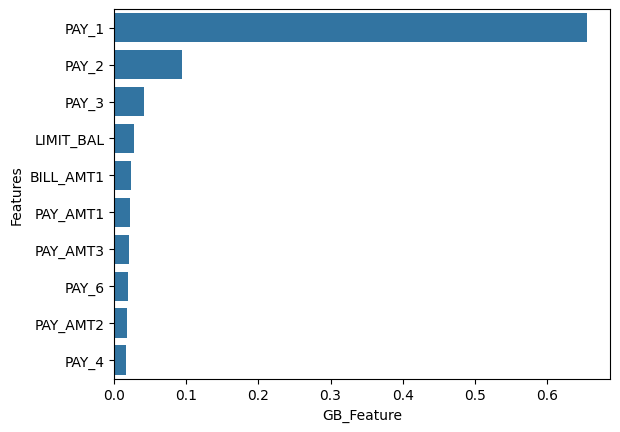

In [36]:
sns.barplot(data=top_10_gb_features,y="Features",x="GB_Feature",)